In [48]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations_CrippaMoure_adapted import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function, Expression
import pickle
from basix.ufl import element
import ufl
from scipy.interpolate import griddata

In [101]:
layer_params = [{
    "top": {"d_i": 0.406e-3, "rho_s": 444,
        "locator": lambda x: x[1] >= 0.1},
    "bottom": {"d_i": 1.463e-3, "rho_s": 484,
        "locator": lambda x: x[1] < 0.1},
        },
        {
    "top": {"d_i": 0.406e-3, "rho_s": 442,
        "locator": lambda x: x[1] >= 0.08},
    "bottom": {"d_i": 1.463e-3, "rho_s": 487,
        "locator": lambda x: x[1] < 0.08},
        },
        {
    "top": {"d_i": 0.406e-3, "rho_s": 455,
        "locator": lambda x: x[1] >= 0.1},
    "bottom": {"d_i": 1.463e-3, "rho_s": 510,
        "locator": lambda x: x[1] < 0.1},
        }]
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
LWCs = []
times = []
z_lines = []

for i in range(3):
    filename = "./solutions/Test_Avanzi_FM" + str(i+1) + ".pkl"
    with open(filename, "rb") as f:
        data_Annika = pickle.load(f)
    nx = data_Annika["geometry"]["nx"]
    nz = data_Annika["geometry"]["nz"]
    geom = Geometry()
    geom.make_from_dict(data_Annika["geometry"])
    domain = geom.make_domain(nx, nz)
    [P0, P1, P2, P3] = geom.corner_points
    V = functionspace(domain, ("CG", 1))
    Q = functionspace(domain, ("DG", 0))
    hw = Function(V)
    phi = Function(Q)
    p = Parameter(domain, layer_params[i])
    hw.x.array[:] = data_Annika["h_w"][-1]
    phi.x.array[:] = data_Annika["phi"]
    z_line = np.linspace(P0[1]+0.02, P3[1], nz)
    x_data = P1[0]/2*np.ones_like(z_line)
    grid = np.column_stack((x_data, z_line))
    pressure_head = eval_fct_on_grid(grid, hw, domain)
    porosity = eval_fct_on_grid(grid, phi, domain)
    h_c = pressure_head * (pressure_head < 0)
    alpha_eval = eval_fct_on_grid(grid, p.alpha, domain)
    N_eval = eval_fct_on_grid(grid, p.N, domain)
    LWCs.append(p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, alpha_eval, N_eval))
    times.append(data_Annika["times"][-1])
    z_lines.append(z_line)



[Text(0, 0.0, ''),
 Text(0, 2.0, ''),
 Text(0, 4.0, ''),
 Text(0, 6.0, ''),
 Text(0, 8.0, ''),
 Text(0, 10.0, ''),
 Text(0, 12.0, ''),
 Text(0, 14.0, ''),
 Text(0, 16.0, ''),
 Text(0, 18.0, ''),
 Text(0, 20.0, '')]

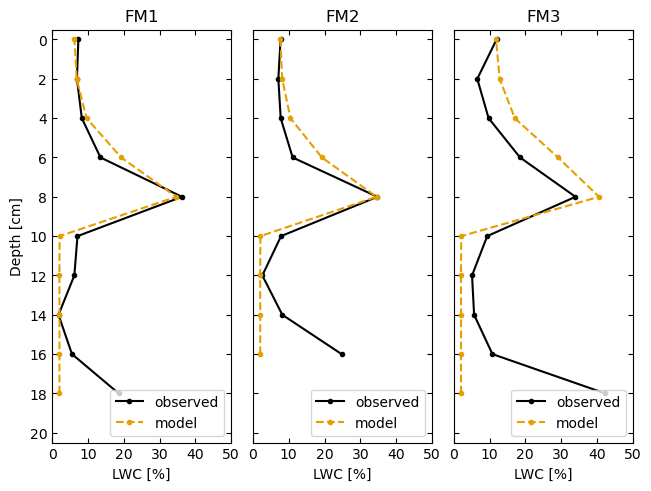

In [105]:
depths = [np.linspace(0, 18, 10), np.linspace(0, 16, 9), np.linspace(0, 18, 10)]
FM1 = np.array(
    [7.314, 6.916, 8.274, 13.488, 36.230, 7.069, 6.190, 1.774, 5.525, 18.572])
FM2 = np.array(
    [7.715, 7.096, 7.751, 11.090, 34.737, 7.850, 2.631, 8.198, 24.754])
FM3 = np.array(
    [11.965, 6.584, 9.743, 18.523, 33.998, 9.353, 5.124, 5.702, 10.815, 42.317])
Experiments = [FM1, FM2, FM3]

colors = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7'] # colour-blind friendly palette (Okabe-Ito)
fig, ax = plt.subplots(1,3, layout="constrained")
for i in range(3):
    color = colors[i % len(colors)]
    ax[i].plot(np.flip(Experiments[i]), np.flip(depths[i]),
               ".-", label=f"observed", color=colors[0])
    ax[i].plot(LWCs[i]*100, np.flip(depths[i]),
              ".--", label=f"model", color=colors[1])
    ax[i].set_xlabel("LWC [%]")
    ax[i].set_title(f"FM{i+1}")
    ax[i].set_ylim(-0.5,20.5)
    ax[i].invert_yaxis()
    ax[i].set_yticks(np.linspace(0, 20, 11))
    ax[i].set_xticks(np.linspace(0, 50, 6))
    ax[i].tick_params(tick2On=True, direction="in")
    ax[i].legend(loc="lower right")
ax[0].set_ylabel("Depth [cm]")
ax[1].set_yticklabels("")
ax[2].set_yticklabels("")

In [109]:
np.mean(np.abs(Experiments[0][5] - np.flip(LWCs[0][6])*100))

np.float64(12.201356056219591)

In [124]:
max(LWCs[1])*100 - max(Experiments[1])

np.float64(-0.20718946753537182)

In [118]:
Experiments[0]

array([ 7.314,  6.916,  8.274, 13.488, 36.23 ,  7.069,  6.19 ,  1.774,
        5.525, 18.572])

#### Depth-averaged?

In [12]:
layer_params = [{
    "top": {"d_i": 0.406e-3, "rho_s": 444,
        "locator": lambda x: x[1] >= 0.1},
    "bottom": {"d_i": 1.463e-3, "rho_s": 484,
        "locator": lambda x: x[1] < 0.1},
        },
        {
    "top": {"d_i": 0.406e-3, "rho_s": 442,
        "locator": lambda x: x[1] >= 0.08},
    "bottom": {"d_i": 1.463e-3, "rho_s": 487,
        "locator": lambda x: x[1] < 0.08},
        },
        {
    "top": {"d_i": 0.406e-3, "rho_s": 455,
        "locator": lambda x: x[1] >= 0.1},
    "bottom": {"d_i": 1.463e-3, "rho_s": 510,
        "locator": lambda x: x[1] < 0.1},
        }]
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
LWCs = []
times = []
z_lines = []

for i in range(3):
    filename = "./solutions/Test_Avanzi_FM" + str(i+1) + "_highres.pkl"
    with open(filename, "rb") as f:
        data_Annika = pickle.load(f)
    nx = data_Annika["geometry"]["nx"]
    nz = data_Annika["geometry"]["nz"]
    geom = Geometry()
    geom.make_from_dict(data_Annika["geometry"])
    domain = geom.make_domain(nx, nz)
    [P0, P1, P2, P3] = geom.corner_points
    V = functionspace(domain, ("CG", 1))
    Q = functionspace(domain, ("DG", 0))
    hw = Function(V)
    phi = Function(Q)
    p = Parameter(domain, layer_params[i])
    hw.x.array[:] = data_Annika["h_w"][-1]
    phi.x.array[:] = data_Annika["phi"]
    z_line = np.linspace(P0[1], P3[1], nz+1)
    x_data = P1[0]/2*np.ones_like(z_line)
    grid = np.column_stack((x_data, z_line))
    pressure_head = eval_fct_on_grid(grid, hw, domain)
    porosity = eval_fct_on_grid(grid, phi, domain)
    h_c = pressure_head * (pressure_head < 0)
    alpha_eval = eval_fct_on_grid(grid, p.alpha, domain)
    N_eval = eval_fct_on_grid(grid, p.N, domain)
    LWCs.append(p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, alpha_eval, N_eval))
    times.append(data_Annika["times"][-1])
    z_lines.append(z_line)


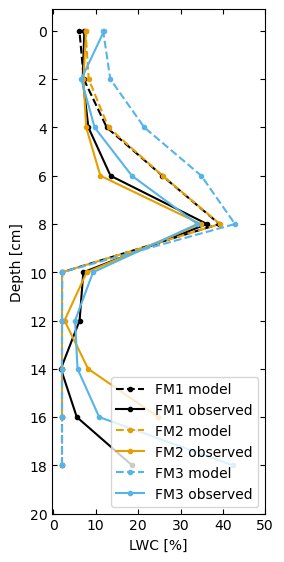

In [16]:
# get average of 2cm slices
avg_LWC = []
for j in range(3):
    avg_LWC.append([100*np.mean(LWCs[j][i:i+4]) for i in range(1, len(LWCs[j]), 4)])
fig1, ax1 = plt.subplots(1,1, figsize=(2.75,6.55))
for i in range(3):
    color = colors[i % len(colors)]
    ax1.plot(avg_LWC[i], np.flip(depths[i]),
              ".--", label=f"FM{i+1} model", color=color)
    ax1.plot(np.flip(Experiments[i]), np.flip(depths[i]),
             ".-", label=f"FM{i+1} observed", color=color)
ax1.set_xlabel("LWC [%]")
ax1.set_ylabel("Depth [cm]")
ax1.invert_yaxis()
ax1.set_yticks(np.linspace(0, 20, 11))
ax1.set_xticks(np.linspace(0, 50, 6))
ax1.tick_params(tick2On=True, direction="in")
ax1.legend(loc="lower right")
plt.show()